# Summary Statistics and Reporting

This notebook demonstrates comprehensive techniques for generating summary statistics and creating statistical reports in data science projects. We'll cover both basic descriptive statistics and more advanced reporting methods.

## 1. Import Essential Libraries

First, let's import all the necessary libraries for statistical analysis and reporting.

In [1]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import statistical libraries
from scipy import stats

# Import automated reporting libraries
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Display settings for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

## 2. Load and Prepare Sample Data

We'll use multiple datasets to demonstrate different statistical reporting techniques:
1. A built-in dataset from seaborn (tips)
2. A synthetic dataset with various distributions

In [2]:
# Load the tips dataset from seaborn
tips_df = sns.load_dataset('tips')

# Create a synthetic dataset with different distributions
np.random.seed(42)
n_samples = 1000

# Create a DataFrame with different distributions
synthetic_df = pd.DataFrame({
    'normal': np.random.normal(loc=50, scale=10, size=n_samples),
    'uniform': np.random.uniform(low=0, high=100, size=n_samples),
    'exponential': np.random.exponential(scale=10, size=n_samples),
    'bimodal': np.concatenate([
        np.random.normal(loc=30, scale=5, size=n_samples//2),
        np.random.normal(loc=70, scale=5, size=n_samples//2)
    ]),
    'categorical': np.random.choice(['A', 'B', 'C', 'D'], size=n_samples, p=[0.4, 0.3, 0.2, 0.1])
})

# Add some missing values to demonstrate handling
for col in synthetic_df.columns[:-1]:  # Skip categorical column
    mask = np.random.random(n_samples) < 0.05  # 5% missing values
    synthetic_df.loc[mask, col] = np.nan

# Display the first rows of each dataset
print("Tips Dataset:")
display(tips_df.head())

print("\nSynthetic Dataset:")
display(synthetic_df.head())

Tips Dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Synthetic Dataset:


,normal,uniform,exponential,bimodal,categorical
0,54.967,16.748,2.473,26.966,D
1,48.617,10.457,0.374,31.056,D
2,56.477,63.643,1.143,36.000,C
3,65.230,70.648,4.138,27.540,A
4,47.658,3.159,16.225,20.617,C


### Data Preparation

Let's handle missing values and check data types before proceeding with analysis.

In [3]:
# Check for missing values in both datasets
print("Missing values in Tips Dataset:")
print(tips_df.isnull().sum())

print("\nMissing values in Synthetic Dataset:")
print(synthetic_df.isnull().sum())

# Handle missing values in the synthetic dataset
synthetic_df_clean = synthetic_df.copy()
for col in synthetic_df.columns[:-1]:  # Skip categorical column
    # Impute missing values with median for numeric columns
    synthetic_df_clean[col].fillna(synthetic_df[col].median(), inplace=True)

# Verify data types
print("\nData Types - Tips Dataset:")
print(tips_df.dtypes)

print("\nData Types - Synthetic Dataset:")
print(synthetic_df_clean.dtypes)

Missing values in Tips Dataset:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Missing values in Synthetic Dataset:
normal         46
uniform        43
exponential    60
bimodal        46
categorical     0
dtype: int64

Data Types - Tips Dataset:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Data Types - Synthetic Dataset:
normal         float64
uniform        float64
exponential    float64
bimodal        float64
categorical     object
dtype: object


## 3. Calculate Descriptive Statistics

Now let's calculate basic descriptive statistics for our datasets including:
- Measures of central tendency (mean, median, mode)
- Measures of dispersion (standard deviation, variance, range)
- Measures of shape (skewness, kurtosis)

In [4]:
# def calculate_descriptive_stats(df, numeric_only=True):
#     """Calculate comprehensive descriptive statistics for a dataframe"""
#     if numeric_only:
#         df_numeric = df.select_dtypes(include=[np.number])
#     else:
#         df_numeric = df
    
#     # Basic statistics from pandas
#     basic_stats = df_numeric.describe()
    
#     # Additional statistics
#     additional_stats = pd.DataFrame(index=df_numeric.columns)
#     additional_stats.loc['range'] = df_numeric.max() - df_numeric.min()
#     additional_stats.loc['variance'] = df_numeric.var()
#     additional_stats.loc['skewness'] = df_numeric.skew()
#     additional_stats.loc['kurtosis'] = df_numeric.kurt()
#     additional_stats.loc['median'] = df_numeric.median()
#     additional_stats.loc['mode'] = df_numeric.mode().iloc[0] if not df_numeric.empty else None
#     additional_stats.loc['missing'] = df_numeric.isnull().sum()
#     additional_stats.loc['missing_pct'] = (df_numeric.isnull().sum() / len(df_numeric)) * 100
    
#     # Combine statistics
#     all_stats = pd.concat([basic_stats, additional_stats.loc[~additional_stats.index.isin(basic_stats.index)]])
    
#     return all_stats

# # Calculate statistics for Tips dataset
# tips_stats = calculate_descriptive_stats(tips_df)
# print("Descriptive Statistics for Tips Dataset:")
# display(tips_stats)

# # Calculate statistics for Synthetic dataset
# synthetic_stats = calculate_descriptive_stats(synthetic_df_clean)
# print("\nDescriptive Statistics for Synthetic Dataset:")
# display(synthetic_stats)

```
ValueError: cannot set a frame with no defined columns
```

In [5]:
import numpy as np
import pandas as pd

def calculate_descriptive_stats(df, numeric_only=True):
    """Calculate comprehensive descriptive statistics for a dataframe."""
    if numeric_only:
        df_numeric = df.select_dtypes(include=[np.number])
    else:
        df_numeric = df

    # If no numeric columns exist, return an empty DataFrame or a message
    if df_numeric.shape[1] == 0:
        return pd.DataFrame({"Note": ["No numeric columns found in the dataset."]})

    # Basic statistics from pandas
    basic_stats = df_numeric.describe()

    # Additional statistics
    additional_stats = pd.DataFrame(columns=df_numeric.columns)
    additional_stats.loc['range'] = df_numeric.max() - df_numeric.min()
    additional_stats.loc['variance'] = df_numeric.var()
    additional_stats.loc['skewness'] = df_numeric.skew()
    additional_stats.loc['kurtosis'] = df_numeric.kurt()
    additional_stats.loc['median'] = df_numeric.median()
    additional_stats.loc['mode'] = df_numeric.mode().iloc[0] if not df_numeric.mode().empty else np.nan
    additional_stats.loc['missing'] = df_numeric.isnull().sum()
    additional_stats.loc['missing_pct'] = (df_numeric.isnull().sum() / len(df_numeric)) * 100

    # Combine statistics
    all_stats = pd.concat([basic_stats, additional_stats.loc[~additional_stats.index.isin(basic_stats.index)]])
    
    return all_stats

# Calculate statistics for Tips dataset
tips_stats = calculate_descriptive_stats(tips_df)
print("Descriptive Statistics for Tips Dataset:")
display(tips_stats)

# Calculate statistics for Synthetic dataset
synthetic_stats = calculate_descriptive_stats(synthetic_df_clean)
print("\nDescriptive Statistics for Synthetic Dataset:")
display(synthetic_stats)

Descriptive Statistics for Tips Dataset:


,total_bill,tip,size
count,244.000,244.000,244.000
mean,19.786,2.998,2.570
std,8.902,1.384,0.951
min,3.070,1.000,1.000
25%,13.348,2.000,2.000
50%,17.795,2.900,2.000
75%,24.127,3.562,3.000
max,50.810,10.000,6.000
range,47.740,9.000,5.000
variance,79.253,1.914,0.905



Descriptive Statistics for Synthetic Dataset:


,normal,uniform,exponential,bimodal
count,1000.000,1000.000,1.000e+03,1000.000
mean,50.291,50.402,9.638e+00,50.477
std,9.586,28.200,9.239e+00,20.305
min,17.587,0.322,1.163e-04,15.044
25%,44.006,25.802,3.212e+00,30.519
50%,50.293,51.745,6.833e+00,56.225
75%,56.295,73.585,1.290e+01,70.014
max,88.527,99.941,6.129e+01,84.342
range,70.940,99.620,6.129e+01,69.298
variance,91.890,795.242,8.537e+01,412.288


### Confidence Intervals

Let's calculate confidence intervals for the mean of each numeric variable to understand the precision of our estimates.

In [6]:
def calculate_confidence_intervals(df, confidence=0.95):
    """Calculate confidence intervals for the mean of each numeric column"""
    df_numeric = df.select_dtypes(include=[np.number])
    
    result = pd.DataFrame(index=df_numeric.columns)
    result['mean'] = df_numeric.mean()
    
    for column in df_numeric.columns:
        data = df_numeric[column].dropna()
        n = len(data)
        mean = data.mean()
        std_err = stats.sem(data)
        h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
        
        result.loc[column, 'lower_ci'] = mean - h
        result.loc[column, 'upper_ci'] = mean + h
        result.loc[column, 'ci_width'] = h * 2
    
    return result

# Calculate 95% confidence intervals for Tips dataset
tips_ci = calculate_confidence_intervals(tips_df)
print("95% Confidence Intervals for Tips Dataset:")
display(tips_ci)

# Calculate 95% confidence intervals for Synthetic dataset
synthetic_ci = calculate_confidence_intervals(synthetic_df_clean)
print("\n95% Confidence Intervals for Synthetic Dataset:")
display(synthetic_ci)

95% Confidence Intervals for Tips Dataset:


,mean,lower_ci,upper_ci,ci_width
total_bill,19.786,18.663,20.909,2.245
tip,2.998,2.824,3.173,0.349
size,2.570,2.450,2.690,0.240



95% Confidence Intervals for Synthetic Dataset:


,mean,lower_ci,upper_ci,ci_width
normal,50.291,49.697,50.886,1.190
uniform,50.402,48.652,52.152,3.500
exponential,9.638,9.064,10.211,1.147
bimodal,50.477,49.217,51.737,2.520


## 4. Generate Statistical Summaries

Let's use pandas built-in functions to create comprehensive summaries, including groupby operations for segmented analysis.

In [7]:
# # Basic info about the Tips dataset
# print("Tips Dataset Info:")
# tips_df.info()

# # Value counts for categorical variables in Tips dataset
# print("\nTips Dataset - Day Distribution:")
# print(tips_df['day'].value_counts())

# print("\nTips Dataset - Time Distribution:")
# print(tips_df['time'].value_counts())

# # Groupby operations for segmented analysis
# print("\nTips by Day and Time:")
# display(tips_df.groupby(['day', 'time']).agg({
#     'total_bill': ['count', 'mean', 'std', 'min', 'max'],
#     'tip': ['mean', 'std', 'min', 'max'],
#     'tip_pct': lambda x: (tips_df.loc[x.index, 'tip'] / tips_df.loc[x.index, 'total_bill']).mean()
# }).round(2))

# # Let's add a tip percentage column for analysis
# tips_df['tip_pct'] = tips_df['tip'] / tips_df['total_bill']

# # Group statistics by smoker/non-smoker
# print("\nTips Statistics by Smoker Status:")
# display(tips_df.groupby('smoker').agg({
#     'total_bill': ['count', 'mean', 'median', 'std'],
#     'tip': ['mean', 'median', 'std'],
#     'tip_pct': ['mean', 'median', 'std']
# }).round(3))

# # For synthetic data, let's analyze numeric columns
# print("\nSynthetic Dataset - Basic Statistics:")
# display(synthetic_df_clean.describe().T)

# # Distribution of categorical variable
# print("\nSynthetic Dataset - Categorical Distribution:")
# display(synthetic_df_clean['categorical'].value_counts(normalize=True).to_frame('percentage').reset_index().rename(columns={'index': 'category'}))

```
KeyError: "Column(s) ['tip_pct'] do not exist"
```

In [8]:
# Basic info about the Tips dataset
print("Tips Dataset Info:")
tips_df.info()

# Let's add a tip percentage column for analysis (move this up!)
tips_df['tip_pct'] = tips_df['tip'] / tips_df['total_bill']

# Value counts for categorical variables in Tips dataset
print("\nTips Dataset - Day Distribution:")
print(tips_df['day'].value_counts())

print("\nTips Dataset - Time Distribution:")
print(tips_df['time'].value_counts())

# Groupby operations for segmented analysis
print("\nTips by Day and Time:")
display(tips_df.groupby(['day', 'time']).agg({
    'total_bill': ['count', 'mean', 'std', 'min', 'max'],
    'tip': ['mean', 'std', 'min', 'max'],
    'tip_pct': 'mean'  # Now 'tip_pct' exists, so this works
}).round(2))

# Group statistics by smoker/non-smoker
print("\nTips Statistics by Smoker Status:")
display(tips_df.groupby('smoker').agg({
    'total_bill': ['count', 'mean', 'median', 'std'],
    'tip': ['mean', 'median', 'std'],
    'tip_pct': ['mean', 'median', 'std']
}).round(3))

# For synthetic data, let's analyze numeric columns
print("\nSynthetic Dataset - Basic Statistics:")
display(synthetic_df_clean.describe().T)

# Distribution of categorical variable
print("\nSynthetic Dataset - Categorical Distribution:")
display(
    synthetic_df_clean['categorical']
    .value_counts(normalize=True)
    .to_frame('percentage')
    .reset_index()
    .rename(columns={'index': 'category'})
)

Tips Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Tips Dataset - Day Distribution:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Tips Dataset - Time Distribution:
time
Dinner    176
Lunch      68
Name: count, dtype: int64

Tips by Day and Time:


total_bill                              tip                     \
                 count   mean   std    min    max  mean   std   min    max   
day  time                                                                    
Thur Lunch          61  17.66  7.95   7.51  43.11  2.77  1.25  1.25   6.70   
     Dinner          1  18.78   NaN  18.78  18.78  3.00   NaN  3.00   3.00   
Fri  Lunch           7  12.85  2.84   8.58  16.27  2.38  0.66  1.58   3.48   
     Dinner         12  19.66  9.47   5.75  40.17  2.94  1.16  1.00   4.73   
Sat  Lunch           0    NaN   NaN    NaN    NaN   NaN   NaN   NaN    NaN   
     Dinner         87  20.44  9.48   3.07  50.81  2.99  1.63  1.00  10.00   
Sun  Lunch           0    NaN   NaN    NaN    NaN   NaN   NaN   NaN    NaN   
     Dinner         76  21.41  8.83   7.25  48.17  3.26  1.23  1.01   6.50   

            tip_pct  
               mean  
day  time            
Thur Lunch     0.16  
     Dinner    0.16  
Fri  Lunch     0.19  
     Dinner    0.16  
Sat  Lunch      NaN  
     Dinner    0.15  
Sun  Lunch      NaN  
     Dinner    0.17


Tips Statistics by Smoker Status:


total_bill                          tip               tip_pct         \
            count    mean median    std   mean median    std    mean median   
smoker                                                                        
Yes            93  20.756  17.92  9.832  3.009   3.00  1.401   0.163  0.154   
No            151  19.188  17.59  8.256  2.992   2.74  1.377   0.159  0.156   

               
          std  
smoker         
Yes     0.085  
No      0.040


Synthetic Dataset - Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
normal,1000.0,50.291,9.586,1.759e+01,44.006,50.293,56.295,88.527
uniform,1000.0,50.402,28.200,3.218e-01,25.802,51.745,73.585,99.941
exponential,1000.0,9.638,9.239,1.163e-04,3.212,6.833,12.901,61.288
bimodal,1000.0,50.477,20.305,1.504e+01,30.519,56.225,70.014,84.342



Synthetic Dataset - Categorical Distribution:


,categorical,percentage
0,A,0.416
1,B,0.281
2,C,0.200
3,D,0.103


## 5. Visual Statistical Reporting

Now let's create visualizations to illustrate the statistical properties of our data.

Distributions of Numeric Variables in Tips Dataset:


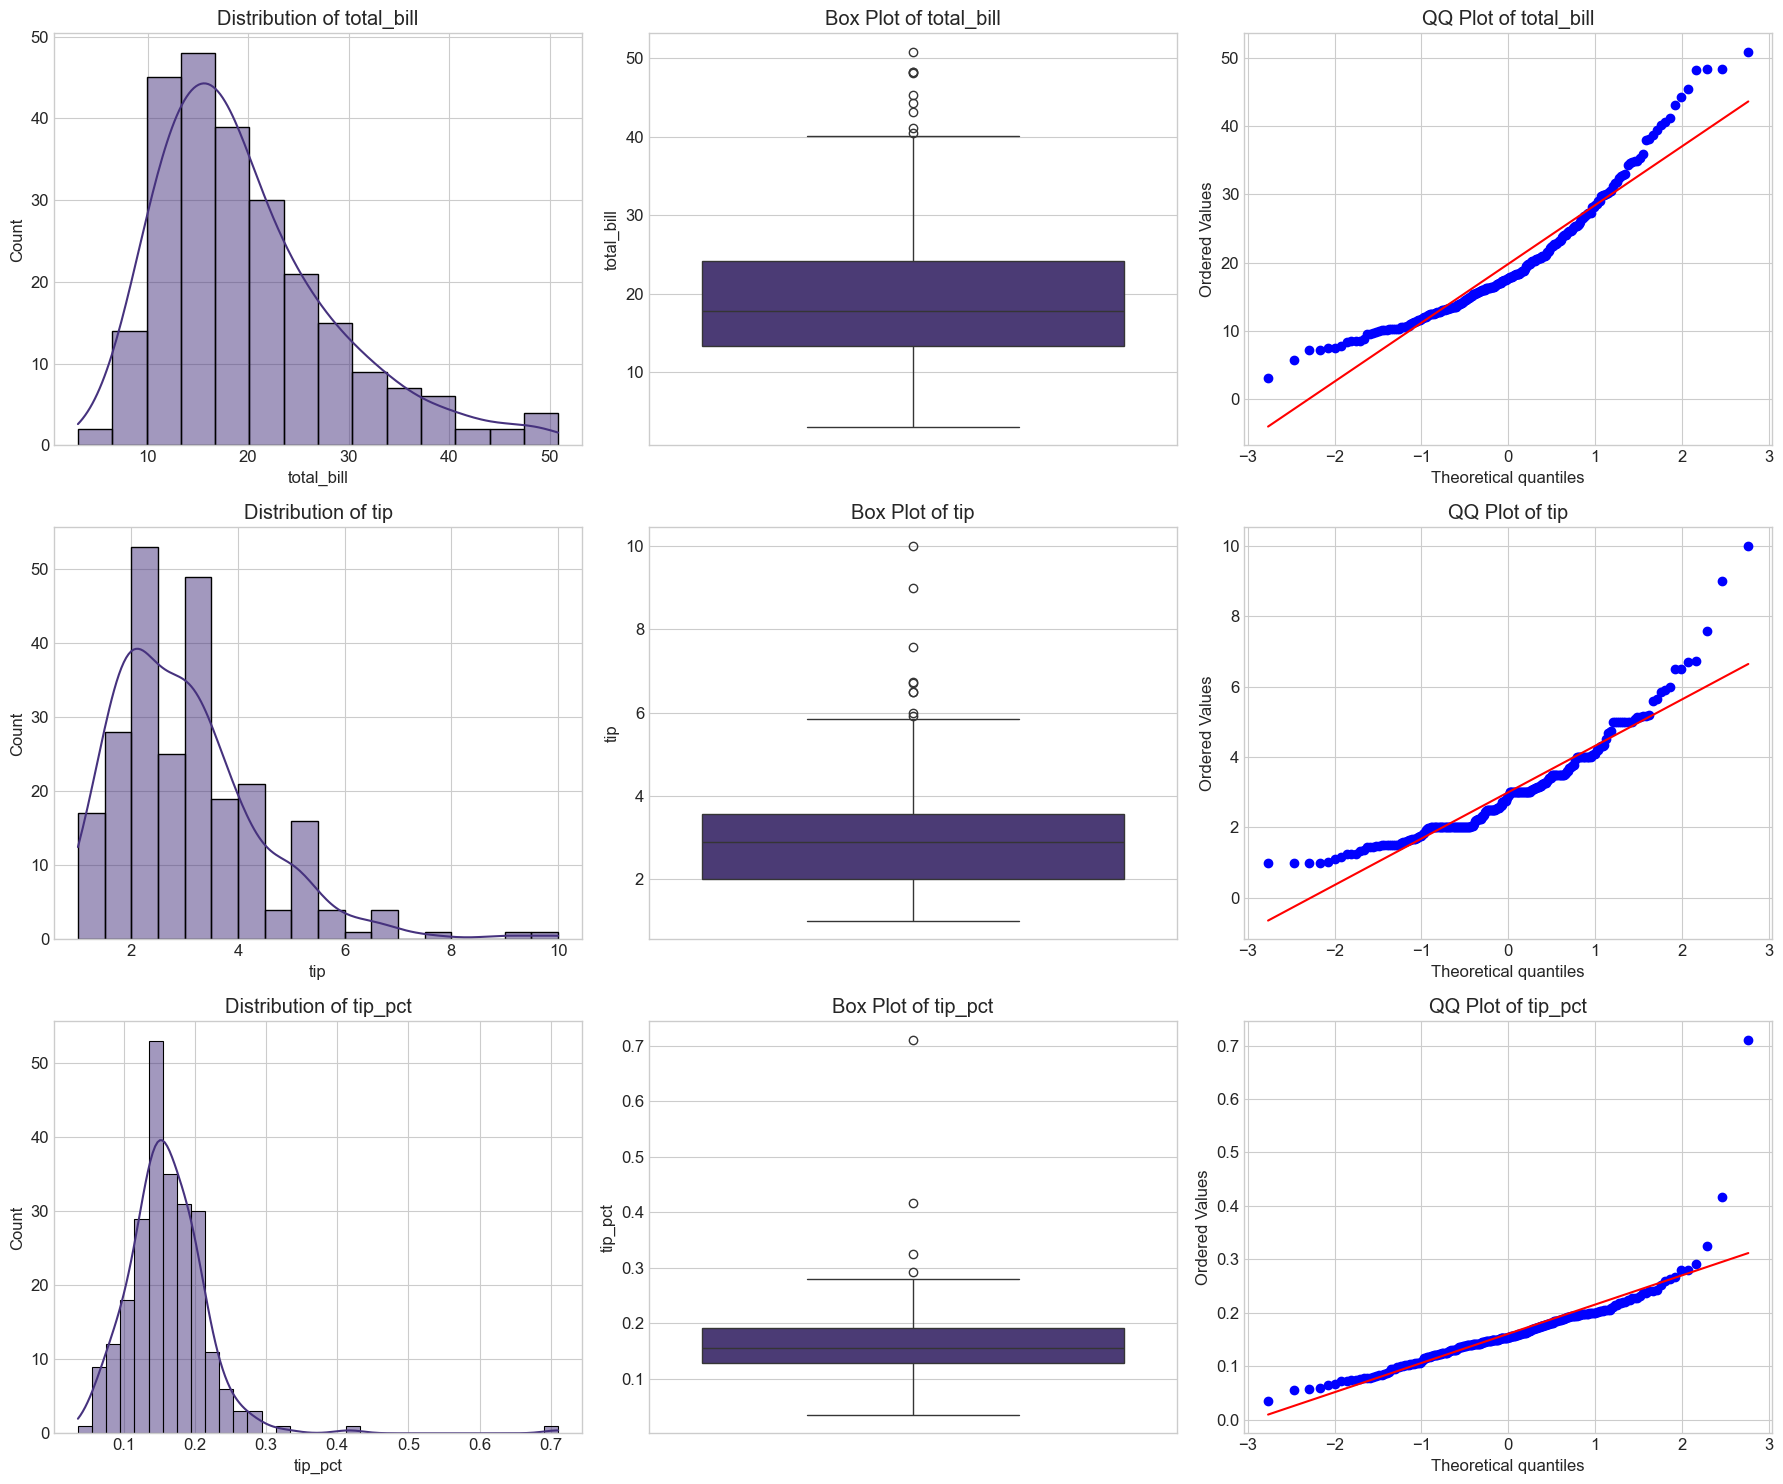

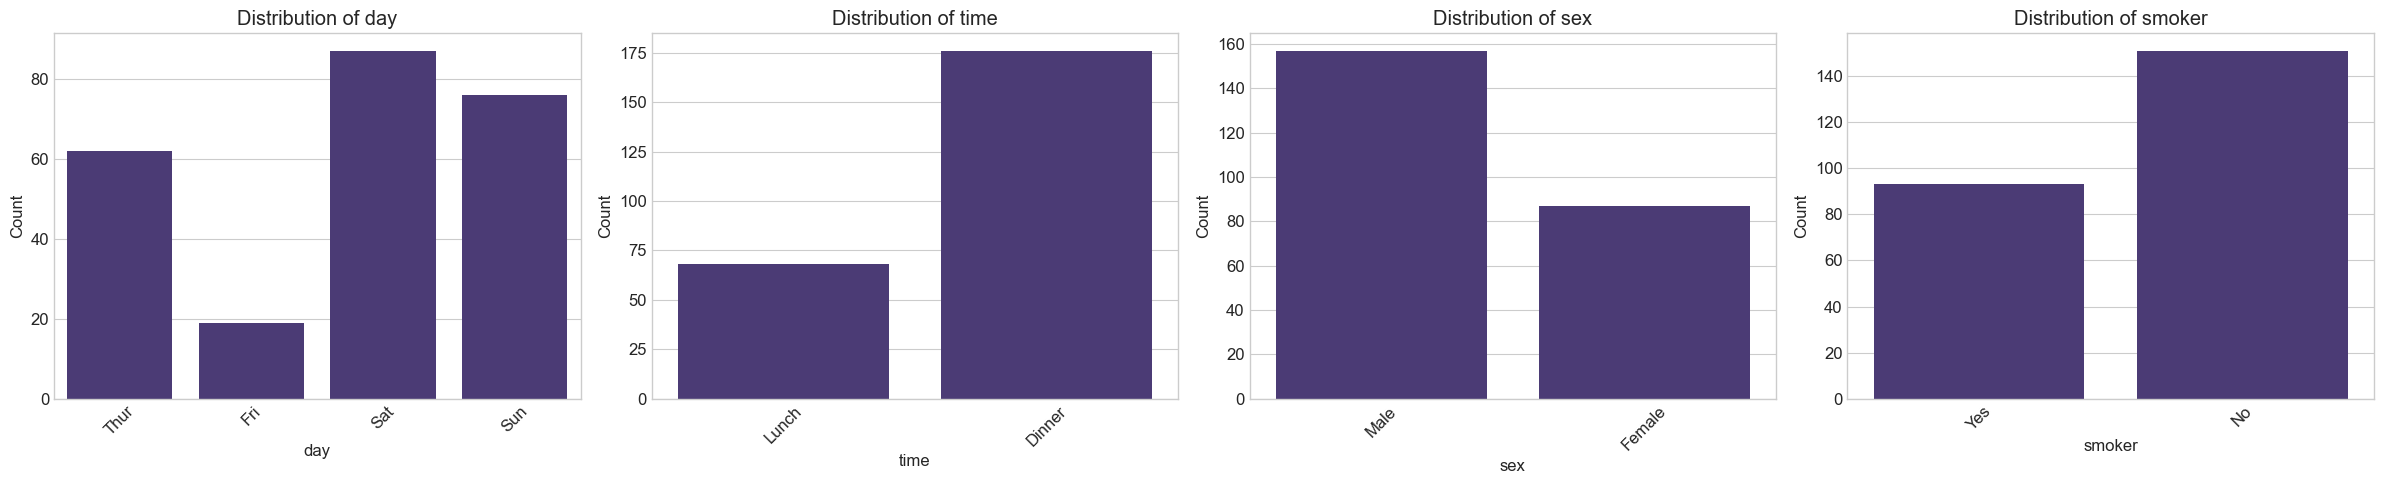


Distributions of Numeric Variables in Synthetic Dataset:


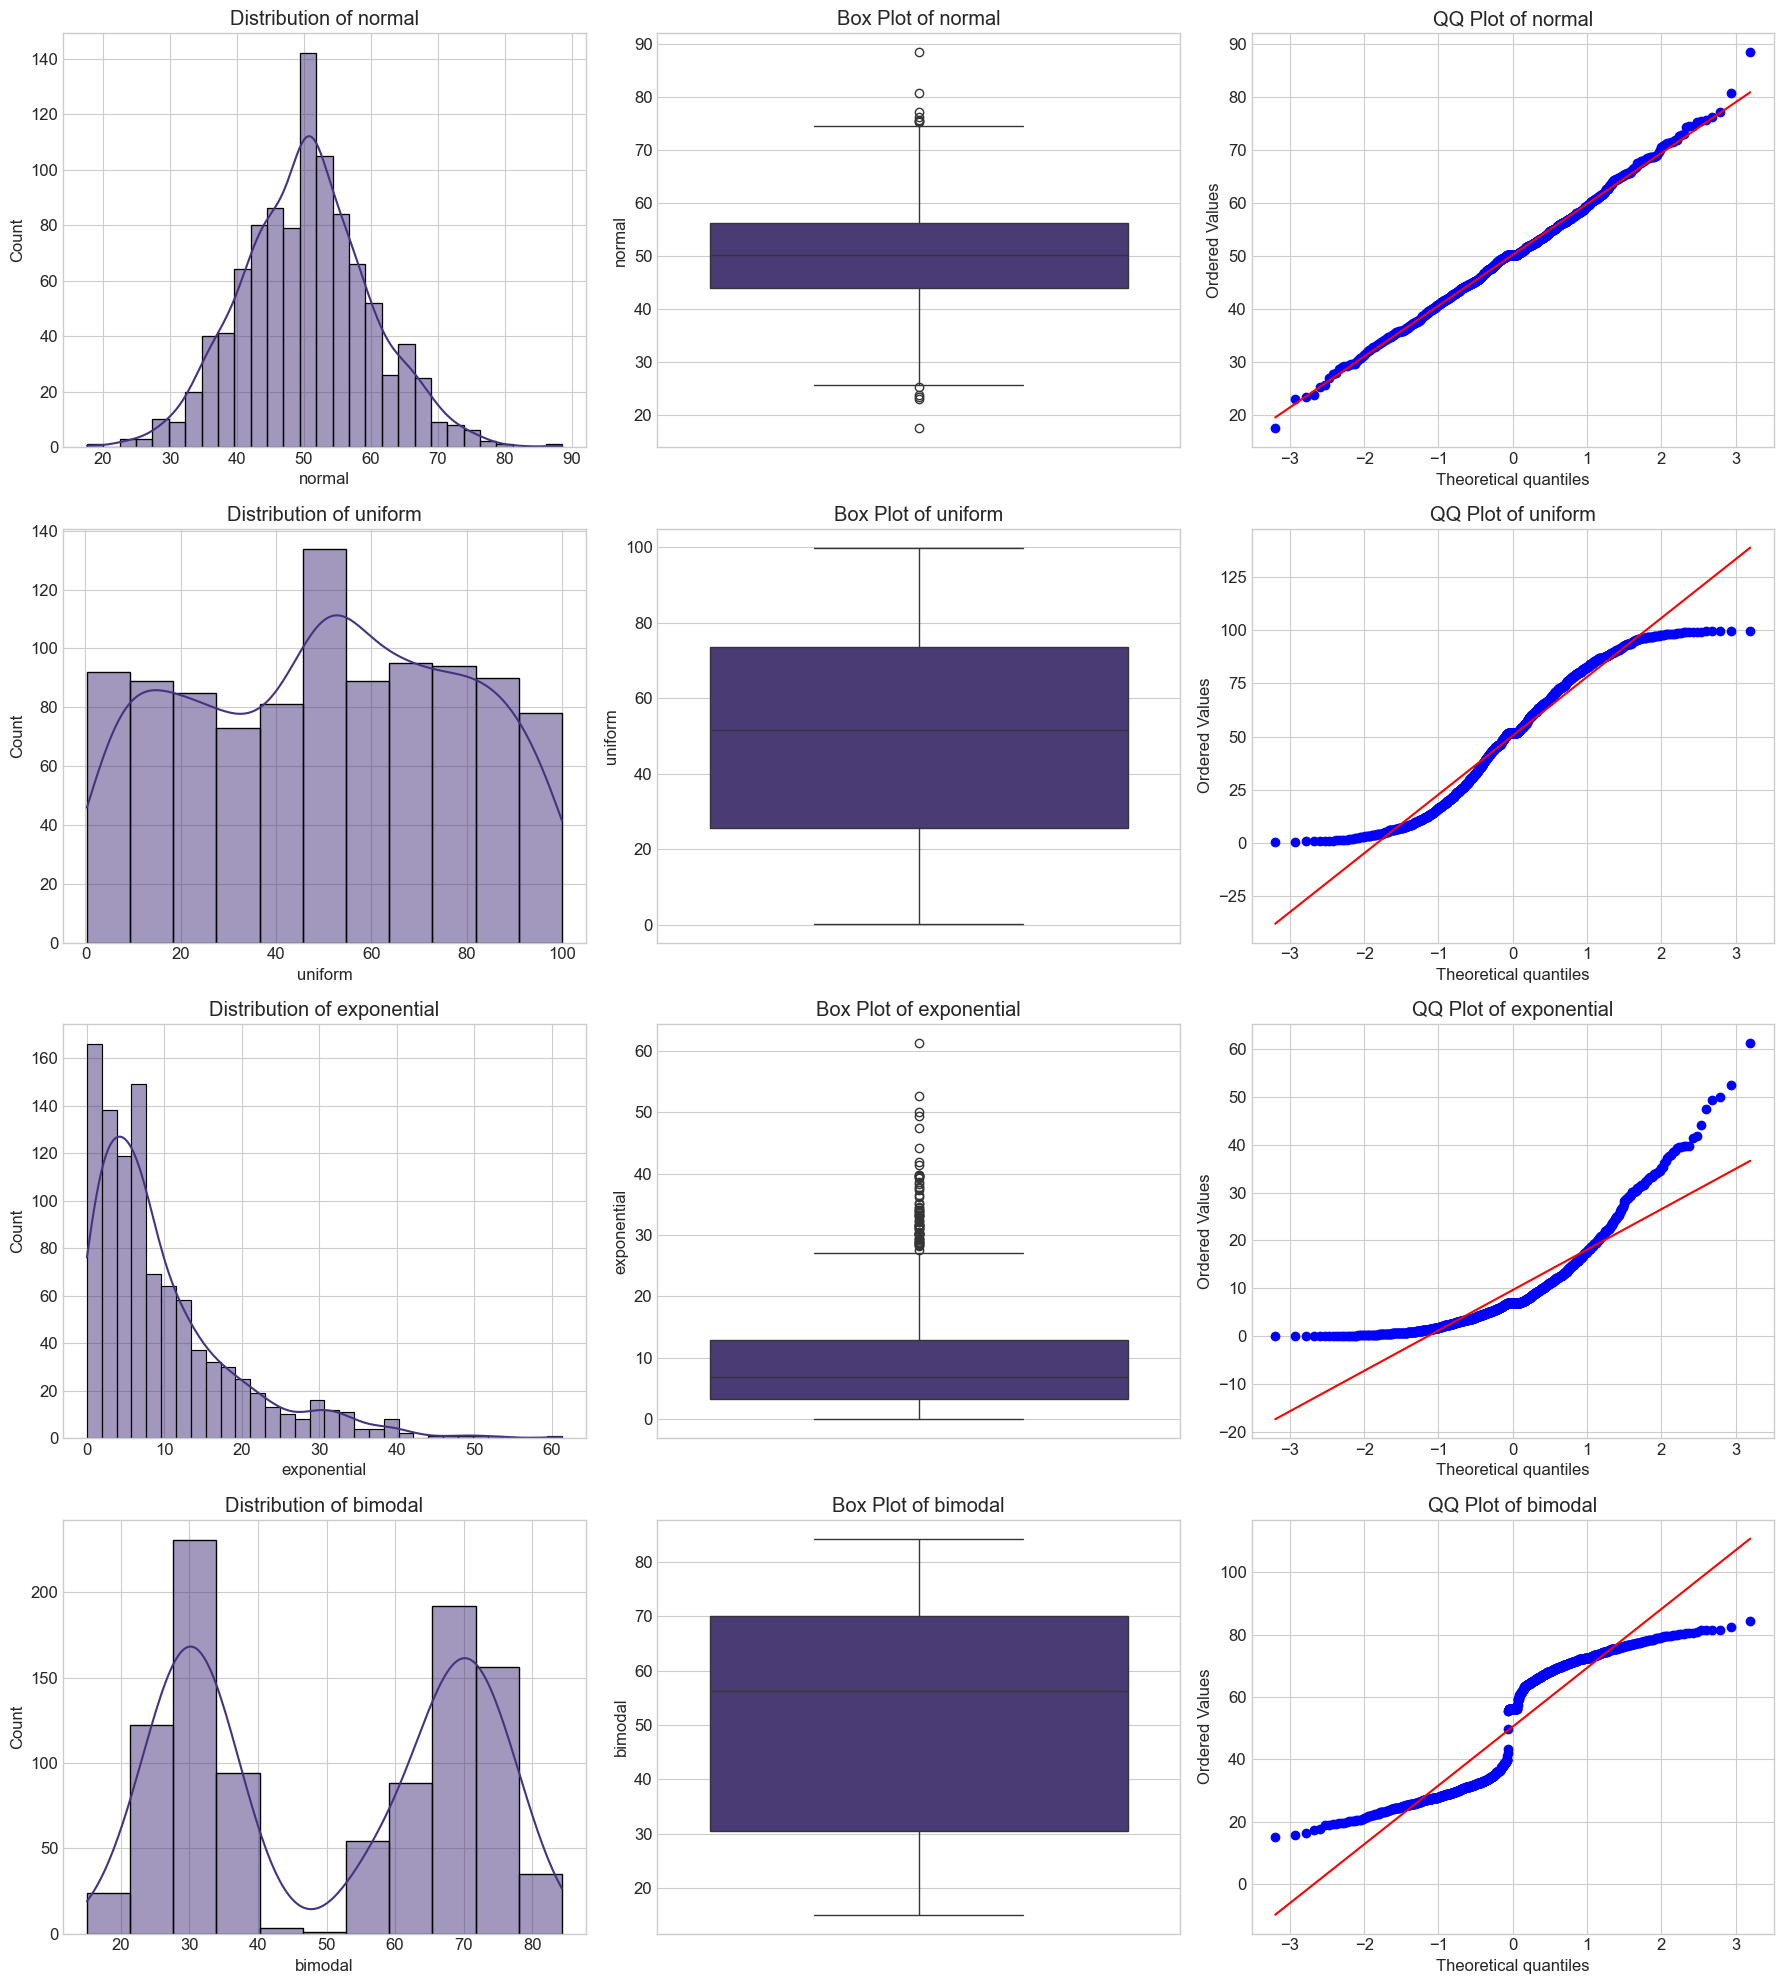

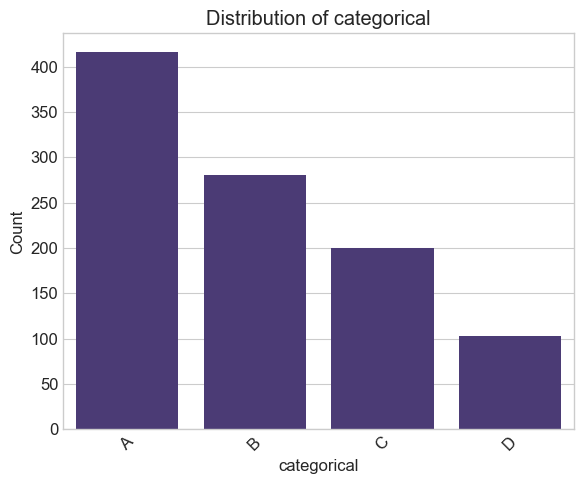

In [9]:
# Create a function for visualizing distributions
def visualize_distributions(df, numeric_columns, categorical_columns=None):
    """Visualize distributions of numeric and categorical columns"""
    
    # Numeric distributions
    if len(numeric_columns) > 0:
        fig, axes = plt.subplots(len(numeric_columns), 3, figsize=(18, 5 * len(numeric_columns)))
        
        if len(numeric_columns) == 1:
            axes = axes.reshape(1, -1)
            
        for i, col in enumerate(numeric_columns):
            # Histogram
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
            axes[i, 0].set_title(f'Distribution of {col}')
            axes[i, 0].set_xlabel(col)
            
            # Box plot
            sns.boxplot(y=df[col].dropna(), ax=axes[i, 1])
            axes[i, 1].set_title(f'Box Plot of {col}')
            axes[i, 1].set_ylabel(col)
            
            # QQ plot to check normality
            stats.probplot(df[col].dropna(), plot=axes[i, 2])
            axes[i, 2].set_title(f'QQ Plot of {col}')
        
        plt.tight_layout()
        plt.show()
    
    # Categorical distributions
    if categorical_columns and len(categorical_columns) > 0:
        fig, axes = plt.subplots(1, len(categorical_columns), figsize=(6 * len(categorical_columns), 5))
        
        if len(categorical_columns) == 1:
            axes = [axes]
            
        for i, col in enumerate(categorical_columns):
            value_counts = df[col].value_counts().sort_values(ascending=False)
            sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].set_ylabel('Count')
            axes[i].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# Visualize distributions for tips dataset
print("Distributions of Numeric Variables in Tips Dataset:")
visualize_distributions(tips_df, ['total_bill', 'tip', 'tip_pct'], ['day', 'time', 'sex', 'smoker'])

# Visualize distributions for synthetic dataset
print("\nDistributions of Numeric Variables in Synthetic Dataset:")
visualize_distributions(synthetic_df_clean, ['normal', 'uniform', 'exponential', 'bimodal'], ['categorical'])

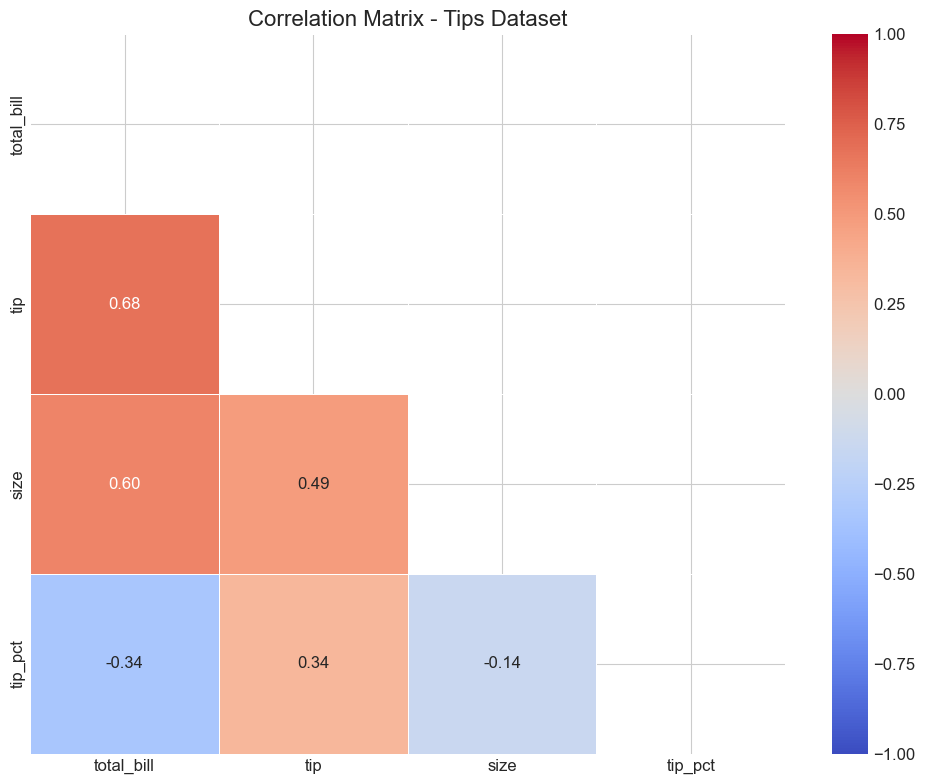

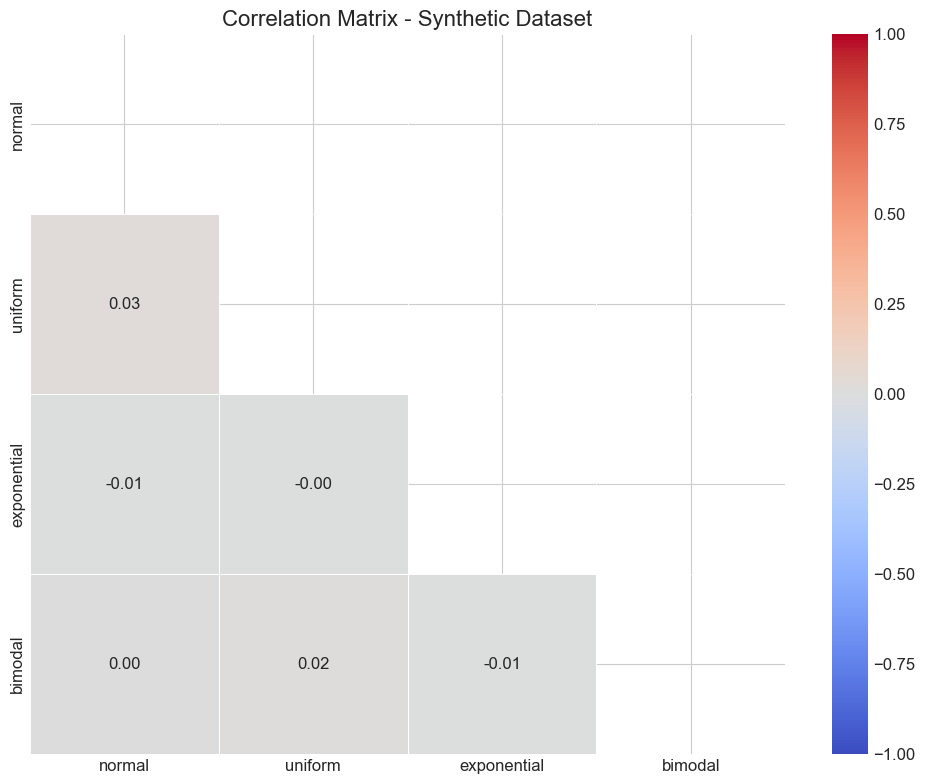

In [10]:
# Create correlation matrix visualization for numeric variables
def visualize_correlations(df, title="Correlation Matrix"):
    """Create a correlation matrix visualization"""
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                mask=mask, vmin=-1, vmax=1, linewidths=0.5)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Visualize correlations for tips dataset
tips_corr = visualize_correlations(tips_df, "Correlation Matrix - Tips Dataset")

# Visualize correlations for synthetic dataset
synthetic_corr = visualize_correlations(synthetic_df_clean, "Correlation Matrix - Synthetic Dataset")

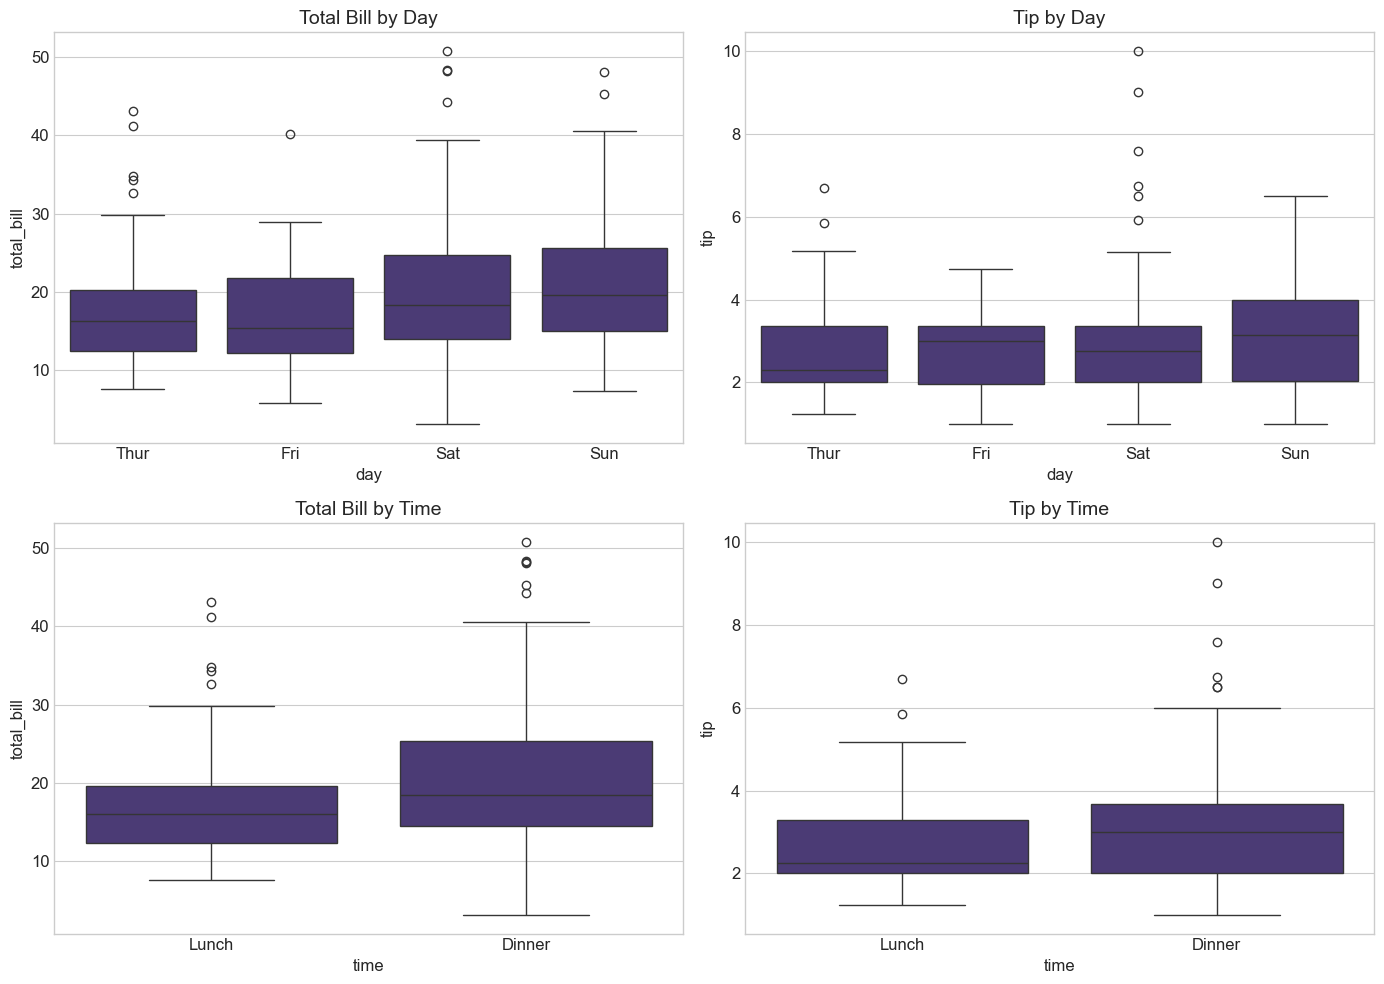

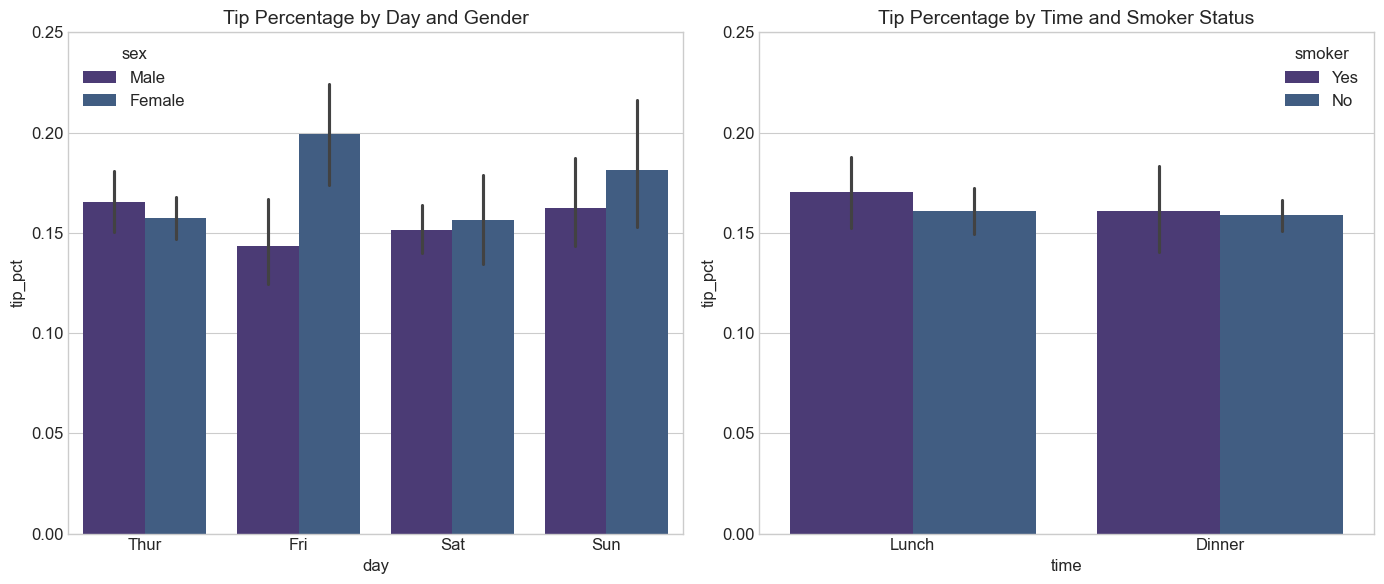

In [11]:
# Create plots for segmented analysis
plt.figure(figsize=(14, 10))

# Create a 2x2 grid of plots
plt.subplot(2, 2, 1)
sns.boxplot(x="day", y="total_bill", data=tips_df)
plt.title("Total Bill by Day", fontsize=14)

plt.subplot(2, 2, 2)
sns.boxplot(x="day", y="tip", data=tips_df)
plt.title("Tip by Day", fontsize=14)

plt.subplot(2, 2, 3)
sns.boxplot(x="time", y="total_bill", data=tips_df)
plt.title("Total Bill by Time", fontsize=14)

plt.subplot(2, 2, 4)
sns.boxplot(x="time", y="tip", data=tips_df)
plt.title("Tip by Time", fontsize=14)

plt.tight_layout()
plt.show()

# Interaction between categorical variables and tip percentage
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x="day", y="tip_pct", hue="sex", data=tips_df)
plt.title("Tip Percentage by Day and Gender", fontsize=14)
plt.ylim(0, 0.25)

plt.subplot(1, 2, 2)
sns.barplot(x="time", y="tip_pct", hue="smoker", data=tips_df)
plt.title("Tip Percentage by Time and Smoker Status", fontsize=14)
plt.ylim(0, 0.25)

plt.tight_layout()
plt.show()

## 6. Custom Summary Functions

Let's create custom summary functions that combine multiple statistics into tailored reports, including confidence intervals and outlier detection.

In [12]:
# def comprehensive_summary(df, group_by=None):
#     """Generate a comprehensive statistical summary, optionally grouped by a variable"""
    
#     # Function to generate statistics for a dataframe
#     def get_stats(df_input):
#         numeric_df = df_input.select_dtypes(include=[np.number])
#         stats_dict = {}
        
#         for col in numeric_df.columns:
#             data = numeric_df[col].dropna()
            
#             # Basic statistics
#             stats = {
#                 'count': len(data),
#                 'missing': numeric_df[col].isna().sum(),
#                 'missing_pct': (numeric_df[col].isna().sum() / len(numeric_df)) * 100,
#                 'mean': data.mean(),
#                 'median': data.median(),
#                 'std': data.std(),
#                 'cv': (data.std() / data.mean()) * 100 if data.mean() != 0 else np.nan,  # Coefficient of variation
#                 'min': data.min(),
#                 'max': data.max(),
#                 'range': data.max() - data.min(),
#                 'q25': data.quantile(0.25),
#                 'q75': data.quantile(0.75),
#                 'iqr': data.quantile(0.75) - data.quantile(0.25),
#                 'skewness': data.skew(),
#                 'kurtosis': data.kurt()
#             }
            
#             # Calculate 95% confidence interval
#             if len(data) > 1:
#                 std_err = stats.sem(data)
#                 ci_95 = std_err * stats.t.ppf((1 + 0.95) / 2, len(data) - 1)
#                 stats.update({
#                     'ci_95_lower': stats['mean'] - ci_95,
#                     'ci_95_upper': stats['mean'] + ci_95,
#                     'ci_95_width': ci_95 * 2
#                 })
            
#             # Detect outliers (outside 1.5 * IQR)
#             q1, q3 = data.quantile(0.25), data.quantile(0.75)
#             iqr = q3 - q1
#             lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
#             outliers = data[(data < lower_bound) | (data > upper_bound)]
            
#             stats.update({
#                 'outliers_count': len(outliers),
#                 'outliers_pct': (len(outliers) / len(data)) * 100 if len(data) > 0 else 0
#             })
            
#             stats_dict[col] = stats
            
#         return pd.DataFrame(stats_dict).T
    
#     if group_by is None:
#         return get_stats(df)
#     else:
#         result_dict = {}
#         for group_name, group_df in df.groupby(group_by):
#             result_dict[group_name] = get_stats(group_df)
#         return result_dict

# # Generate comprehensive summary for tips dataset
# tips_summary = comprehensive_summary(tips_df)
# print("Comprehensive Summary for Tips Dataset:")
# display(tips_summary)

# # Generate grouped summaries for tips dataset by day
# tips_day_summary = comprehensive_summary(tips_df, group_by='day')
# for day, summary in tips_day_summary.items():
#     print(f"\nSummary for {day}:")
#     display(summary)

```
AttributeError: 'dict' object has no attribute 'sem'
```

In [13]:
def comprehensive_summary(df, group_by=None):
    """Generate a comprehensive statistical summary, optionally grouped by a variable"""
    
    def get_stats(df_input):
        numeric_df = df_input.select_dtypes(include=[np.number])
        stats_dict = {}
        
        for col in numeric_df.columns:
            data = numeric_df[col].dropna()
            
            # Basic statistics
            col_stats = {
                'count': len(data),
                'missing': numeric_df[col].isna().sum(),
                'missing_pct': (numeric_df[col].isna().sum() / len(numeric_df)) * 100,
                'mean': data.mean(),
                'median': data.median(),
                'std': data.std(),
                'cv': (data.std() / data.mean()) * 100 if data.mean() != 0 else np.nan,
                'min': data.min(),
                'max': data.max(),
                'range': data.max() - data.min(),
                'q25': data.quantile(0.25),
                'q75': data.quantile(0.75),
                'iqr': data.quantile(0.75) - data.quantile(0.25),
                'skewness': data.skew(),
                'kurtosis': data.kurt()
            }
            
            # 95% Confidence Interval
            if len(data) > 1:
                std_err = stats.sem(data)  # this now refers to scipy.stats
                ci_95 = std_err * stats.t.ppf((1 + 0.95) / 2, len(data) - 1)
                col_stats.update({
                    'ci_95_lower': col_stats['mean'] - ci_95,
                    'ci_95_upper': col_stats['mean'] + ci_95,
                    'ci_95_width': ci_95 * 2
                })
            
            # Outlier detection
            q1, q3 = data.quantile(0.25), data.quantile(0.75)
            iqr = q3 - q1
            lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            
            col_stats.update({
                'outliers_count': len(outliers),
                'outliers_pct': (len(outliers) / len(data)) * 100 if len(data) > 0 else 0
            })
            
            stats_dict[col] = col_stats
            
        return pd.DataFrame(stats_dict).T
    
    if group_by is None:
        return get_stats(df)
    else:
        result_dict = {}
        for group_name, group_df in df.groupby(group_by):
            result_dict[group_name] = get_stats(group_df)
        return result_dict

# Generate comprehensive summary for tips dataset
tips_summary = comprehensive_summary(tips_df)
print("Comprehensive Summary for Tips Dataset:")
display(tips_summary)

# Generate grouped summaries for tips dataset by day
tips_day_summary = comprehensive_summary(tips_df, group_by='day')
for day, summary in tips_day_summary.items():
    print(f"\nSummary for {day}:")
    display(summary)

Comprehensive Summary for Tips Dataset:


,count,missing,missing_pct,mean,median,std,cv,min,max,range,q25,q75,iqr,skewness,kurtosis,ci_95_lower,ci_95_upper,ci_95_width,outliers_count,outliers_pct
total_bill,244.0,0.0,0.0,19.786,17.795,8.902,44.994,3.070,50.81,47.740,13.348,24.127,10.780,1.133,1.218,18.663,20.909,2.245,9.0,3.689
tip,244.0,0.0,0.0,2.998,2.900,1.384,46.148,1.000,10.00,9.000,2.000,3.562,1.562,1.465,3.648,2.824,3.173,0.349,9.0,3.689
size,244.0,0.0,0.0,2.570,2.000,0.951,37.012,1.000,6.00,5.000,2.000,3.000,1.000,1.448,1.732,2.450,2.690,0.240,9.0,3.689
tip_pct,244.0,0.0,0.0,0.161,0.155,0.061,37.980,0.036,0.71,0.675,0.129,0.191,0.062,3.349,27.131,0.153,0.169,0.015,4.0,1.639



Summary for Thur:


,count,missing,missing_pct,mean,median,std,cv,min,max,range,q25,q75,iqr,skewness,kurtosis,ci_95_lower,ci_95_upper,ci_95_width,outliers_count,outliers_pct
total_bill,62.0,0.0,0.0,17.683,16.200,7.886,44.598,7.510,43.110,35.600,12.442,20.155,7.713,1.361,1.820,15.680,19.685,4.005,5.0,8.065
tip,62.0,0.0,0.0,2.771,2.305,1.240,44.750,1.250,6.700,5.450,2.000,3.362,1.362,1.166,0.802,2.456,3.086,0.630,2.0,3.226
size,62.0,0.0,0.0,2.452,2.000,1.066,43.493,1.000,6.000,5.000,2.000,2.000,0.000,2.268,4.589,2.181,2.722,0.542,14.0,22.581
tip_pct,62.0,0.0,0.0,0.161,0.154,0.039,23.966,0.073,0.266,0.193,0.138,0.193,0.054,0.208,0.210,0.151,0.171,0.020,0.0,0.000



Summary for Fri:


,count,missing,missing_pct,mean,median,std,cv,min,max,range,q25,q75,iqr,skewness,kurtosis,ci_95_lower,ci_95_upper,ci_95_width,outliers_count,outliers_pct
total_bill,19.0,0.0,0.0,17.152,15.380,8.303,48.408,5.750,40.170,34.42,12.095,21.750,9.655,1.317,1.994,13.150,21.153,8.004,1.0,5.263
tip,19.0,0.0,0.0,2.735,3.000,1.020,37.282,1.000,4.730,3.73,1.960,3.365,1.405,0.190,-0.596,2.243,3.226,0.983,0.0,0.000
size,19.0,0.0,0.0,2.105,2.000,0.567,26.939,1.000,4.000,3.00,2.000,2.000,0.000,2.093,7.698,1.832,2.379,0.547,3.0,15.789
tip_pct,19.0,0.0,0.0,0.170,0.156,0.048,28.053,0.104,0.263,0.16,0.134,0.197,0.063,0.581,-0.530,0.147,0.193,0.046,0.0,0.000



Summary for Sat:


,count,missing,missing_pct,mean,median,std,cv,min,max,range,q25,q75,iqr,skewness,kurtosis,ci_95_lower,ci_95_upper,ci_95_width,outliers_count,outliers_pct
total_bill,87.0,0.0,0.0,20.441,18.240,9.480,46.379,3.070,50.810,47.74,13.905,24.740,10.835,1.262,1.716,18.421,22.462,4.041,4.0,4.598
tip,87.0,0.0,0.0,2.993,2.750,1.631,54.492,1.000,10.000,9.00,2.000,3.370,1.370,2.000,5.337,2.645,3.341,0.695,6.0,6.897
size,87.0,0.0,0.0,2.517,2.000,0.819,32.547,1.000,5.000,4.00,2.000,3.000,1.000,0.982,0.108,2.343,2.692,0.349,1.0,1.149
tip_pct,87.0,0.0,0.0,0.153,0.152,0.051,33.491,0.036,0.326,0.29,0.124,0.188,0.064,0.409,1.132,0.142,0.164,0.022,2.0,2.299



Summary for Sun:


,count,missing,missing_pct,mean,median,std,cv,min,max,range,q25,q75,iqr,skewness,kurtosis,ci_95_lower,ci_95_upper,ci_95_width,outliers_count,outliers_pct
total_bill,76.0,0.0,0.0,21.410,19.630,8.832,41.252,7.250,48.17,40.920,14.987,25.598,10.610,0.823,0.422,19.392,23.428,4.036,2.0,2.632
tip,76.0,0.0,0.0,3.255,3.150,1.235,37.936,1.010,6.50,5.490,2.037,4.000,1.963,0.478,-0.359,2.973,3.537,0.564,0.0,0.000
size,76.0,0.0,0.0,2.842,2.000,1.007,35.443,2.000,6.00,4.000,2.000,4.000,2.000,0.889,-0.087,2.612,3.072,0.460,0.0,0.000
tip_pct,76.0,0.0,0.0,0.167,0.161,0.085,50.773,0.059,0.71,0.651,0.120,0.188,0.068,3.862,22.711,0.148,0.186,0.039,2.0,2.632


### Customized Summary with Outlier Detection

Let's create a more focused custom summary with outlier detection and visualization.

Outlier Analysis for 'total_bill'
Number of outliers: 9 (3.69% of data)
Lower bound: -2.82, Upper bound: 40.30
Top 10 outliers:


170    50.81
212    48.33
59     48.27
156    48.17
182    45.35
102    44.30
197    43.11
142    41.19
184    40.55
Name: total_bill, dtype: float64

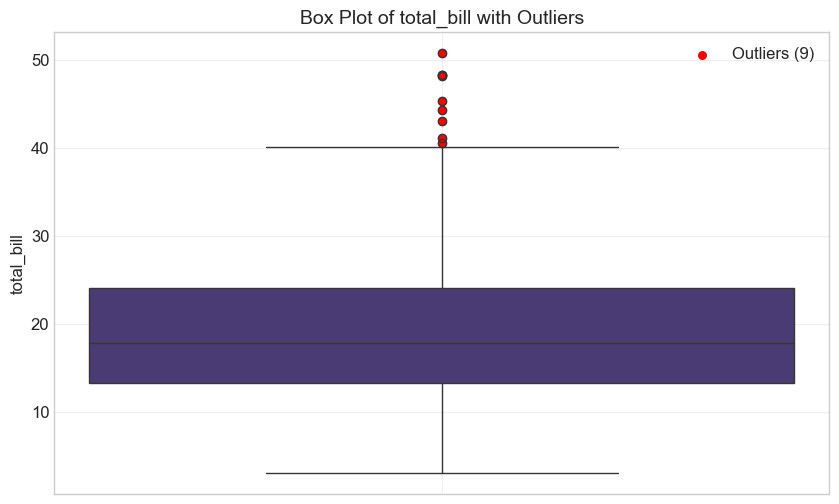


Outlier Analysis for 'total_bill' in day='Thur'
Number of outliers: 5 (8.06% of data)
Lower bound: 0.87, Upper bound: 31.72
Outliers:


197    43.11
142    41.19
85     34.83
141    34.30
83     32.68
Name: total_bill, dtype: float64


Outlier Analysis for 'total_bill' in day='Fri'
Number of outliers: 1 (5.26% of data)
Lower bound: -2.39, Upper bound: 36.23
Outliers:


95    40.17
Name: total_bill, dtype: float64


Outlier Analysis for 'total_bill' in day='Sat'
Number of outliers: 4 (4.60% of data)
Lower bound: -2.35, Upper bound: 40.99
Outliers:


170    50.81
212    48.33
59     48.27
102    44.30
Name: total_bill, dtype: float64


Outlier Analysis for 'total_bill' in day='Sun'
Number of outliers: 2 (2.63% of data)
Lower bound: -0.93, Upper bound: 41.51
Outliers:


156    48.17
182    45.35
Name: total_bill, dtype: float64

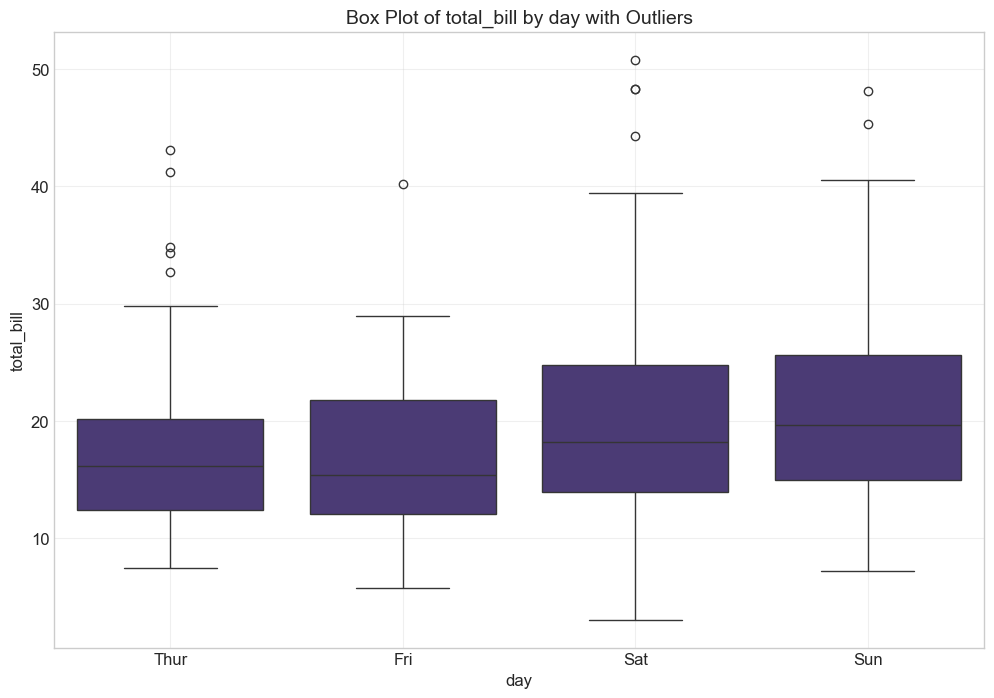

Outlier Analysis for 'normal'
Number of outliers: 12 (1.20% of data)
Lower bound: 25.57, Upper bound: 74.73
Top 10 outliers:


209    88.527
478    80.789
179    77.202
755    76.324
654    75.734
762    75.601
880    75.269
544    25.284
74     23.803
668    23.490
Name: normal, dtype: float64

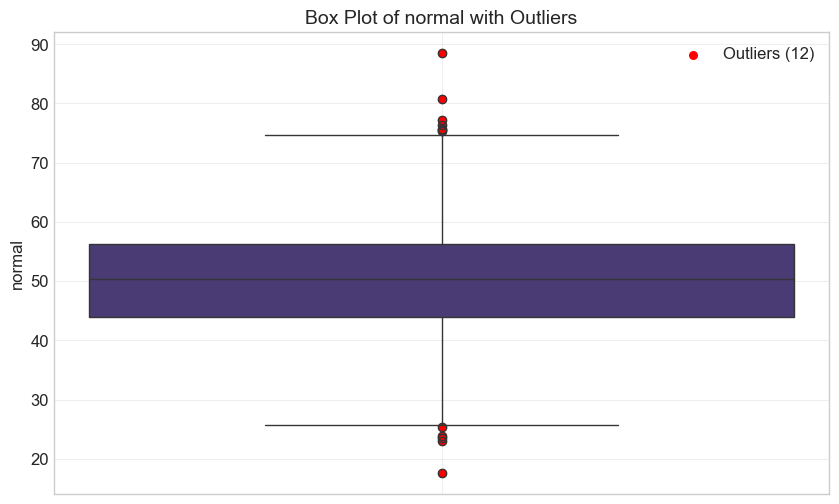

In [14]:
def outlier_analysis(df, column, group_by=None):
    """Perform and visualize outlier analysis for a specific column"""
    
    def detect_outliers(series):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = series[(series < lower_bound) | (series > upper_bound)]
        return outliers, lower_bound, upper_bound
    
    if group_by is None:
        # Overall outlier analysis
        data = df[column].dropna()
        outliers, lower, upper = detect_outliers(data)
        
        print(f"Outlier Analysis for '{column}'")
        print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(data):.2%} of data)")
        print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
        
        if not outliers.empty:
            print("Top 10 outliers:")
            display(outliers.sort_values(ascending=False).head(10))
        
        # Visualize with boxplot
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=df[column])
        plt.title(f"Box Plot of {column} with Outliers", fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # Highlight outliers with scatter points
        if not outliers.empty:
            outlier_indices = outliers.index
            plt.scatter(x=[0] * len(outlier_indices), y=df.loc[outlier_indices, column], 
                       color='red', s=30, label=f'Outliers ({len(outliers)})')
            plt.legend()
        
        plt.show()
        
    else:
        # Grouped outlier analysis
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Box plot by group
        sns.boxplot(x=group_by, y=column, data=df, ax=ax)
        plt.title(f"Box Plot of {column} by {group_by} with Outliers", fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # Print statistics and highlight outliers for each group
        for name, group in df.groupby(group_by):
            data = group[column].dropna()
            outliers, lower, upper = detect_outliers(data)
            
            print(f"\nOutlier Analysis for '{column}' in {group_by}='{name}'")
            print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(data):.2%} of data)")
            print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
            
            if not outliers.empty and len(outliers) < 20:  # Only show if not too many
                print("Outliers:")
                display(outliers.sort_values(ascending=False))
        
        plt.show()

# Perform outlier analysis for total_bill in tips dataset
outlier_analysis(tips_df, 'total_bill')

# Perform outlier analysis for total_bill grouped by day
outlier_analysis(tips_df, 'total_bill', group_by='day')

# Perform outlier analysis for normal distribution in synthetic dataset
outlier_analysis(synthetic_df_clean, 'normal')

## 7. Automated Statistical Reports

Let's demonstrate how to use libraries like pandas-profiling or sweetviz to generate comprehensive statistical reports with minimal code.

**Note**: You may need to install these libraries first:
- `pip install pandas-profiling[notebook]` or `pip install ydata-profiling[notebook]`
- `pip install sweetviz`

In [15]:
# !pip install pandas-profiling[notebook]
# !pip install ydata-profiling[notebook]
# !pip install sweetviz

```
pip install pandas-profiling[notebook]
Getting requirements to build wheel did not run successfully.
exit code: 1

pip install ydata-profiling[notebook]
ERROR: Could not find a version that satisfies the requirement ydata-profiling (from versions: none)
ERROR: No matching distribution found for ydata-profiling
```

In [16]:
# Try to import pandas-profiling (newer version is ydata-profiling)
try:
    try:
        from pandas_profiling import ProfileReport
        profile_module = "pandas_profiling"
    except ImportError:
        from ydata_profiling import ProfileReport
        profile_module = "ydata_profiling"
    
    # Generate a profile report for the tips dataset
    print(f"Generating profile report using {profile_module}...")
    profile = ProfileReport(tips_df, title="Tips Dataset Profiling Report", explorative=True)
    
    # Display the report in notebook
    display(profile.to_notebook_iframe())
    
    # Save the report to HTML file
    # profile.to_file("tips_profile_report.html")
    
except ImportError:
    print("Warning: pandas-profiling or ydata-profiling is not installed.")
    print("To install, run: pip install pandas-profiling[notebook] OR pip install ydata-profiling[notebook]")

To install, run: pip install pandas-profiling[notebook] OR pip install ydata-profiling[notebook]


```
Warning: pandas-profiling or ydata-profiling is not installed.
To install, run: pip install pandas-profiling[notebook] OR pip install ydata-profiling[notebook]
```

In [17]:
# # Try to use sweetviz for automated EDA reporting
# try:
#     import sweetviz as sv
    
#     # Generate a sweetviz report for the tips dataset
#     print("Generating Sweetviz report...")
#     sweet_report = sv.analyze(tips_df)
    
#     # Display the report in notebook
#     sweet_report.show_notebook()
    
#     # Save the report to HTML file
#     # sweet_report.show_html("tips_sweetviz_report.html")
    
# except ImportError:
#     print("Warning: sweetviz is not installed.")
#     print("To install, run: pip install sweetviz")

```
AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'
```

Generating Sweetviz report...


                                             |                                                                …

Error: Your version of NumPy is too new for Sweetviz.
Try downgrading NumPy: pip install numpy==1.23.5


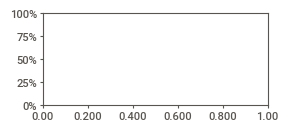

In [18]:
try:
    import sweetviz as sv
    import numpy as np
    
    print("Generating Sweetviz report...")
    sweet_report = sv.analyze(tips_df)
    sweet_report.show_notebook()
    
except ImportError:
    print("Warning: sweetviz is not installed.")
    print("To install, run: pip install sweetviz")

except AttributeError as e:
    if 'VisibleDeprecationWarning' in str(e):
        print("Error: Your version of NumPy is too new for Sweetviz.")
        print("Try downgrading NumPy: pip install numpy==1.23.5")
    else:
        raise  # re-raise other unexpected AttributeErrors

```
Error: Your version of NumPy is too new for Sweetviz.
Try downgrading NumPy: pip install numpy==1.23.5
```

## 8. Exporting Summary Statistics

Let's demonstrate how to export our summary statistics to various formats for sharing with stakeholders.

In [19]:
# Function to export summary statistics to various formats
def export_summary_statistics(df, filename_prefix, formats=None):
    """
    Export summary statistics to various formats
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to generate statistics for
    filename_prefix : str
        Prefix for output filenames
    formats : list
        List of formats to export (csv, excel, html, json)
    """
    if formats is None:
        formats = ['csv', 'excel', 'html', 'json']
    
    # Generate comprehensive statistics
    summary = comprehensive_summary(df)
    
    # Create a styled HTML version for better visualization
    styled_summary = summary.style.background_gradient(cmap='coolwarm', subset=['mean', 'median', 'std'])\
                                 .highlight_max(color='yellow', subset=['outliers_count', 'missing_pct'])\
                                 .set_caption("Comprehensive Statistical Summary")
    
    # Export to selected formats
    if 'csv' in formats:
        summary.to_csv(f"{filename_prefix}_summary_stats.csv")
        print(f"Exported to {filename_prefix}_summary_stats.csv")
    
    if 'excel' in formats:
        try:
            with pd.ExcelWriter(f"{filename_prefix}_summary_stats.xlsx") as writer:
                summary.to_excel(writer, sheet_name="Summary Statistics")
                df.describe().to_excel(writer, sheet_name="Basic Statistics")
                
                # Add correlation matrix if there are numeric columns
                if df.select_dtypes(include=[np.number]).shape[1] > 1:
                    df.corr().to_excel(writer, sheet_name="Correlation Matrix")
                    
            print(f"Exported to {filename_prefix}_summary_stats.xlsx")
        except Exception as e:
            print(f"Failed to export to Excel: {e}")
    
    if 'html' in formats:
        # Export both basic HTML and styled HTML
        summary.to_html(f"{filename_prefix}_summary_stats.html")
        styled_html = styled_summary.to_html()
        with open(f"{filename_prefix}_summary_stats_styled.html", "w") as f:
            f.write(styled_html)
        print(f"Exported to {filename_prefix}_summary_stats.html and {filename_prefix}_summary_stats_styled.html")
    
    if 'json' in formats:
        summary.to_json(f"{filename_prefix}_summary_stats.json", orient="index")
        print(f"Exported to {filename_prefix}_summary_stats.json")
    
    return summary

# Export tips dataset summary (comment out to avoid creating files)
# tips_exported_summary = export_summary_statistics(tips_df, "tips", formats=['csv', 'html'])
print("To export summaries, uncomment the export_summary_statistics function calls")

To export summaries, uncomment the export_summary_statistics function calls


### Creating a PDF Report

We can also create a comprehensive PDF report using libraries like ReportLab or using Matplotlib to save figures that can be included in reports.

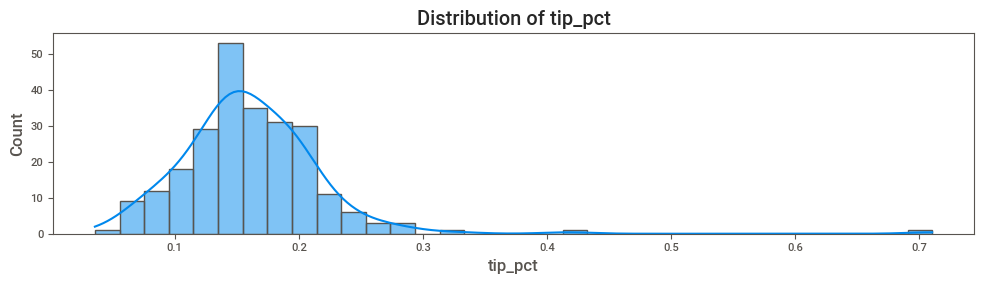

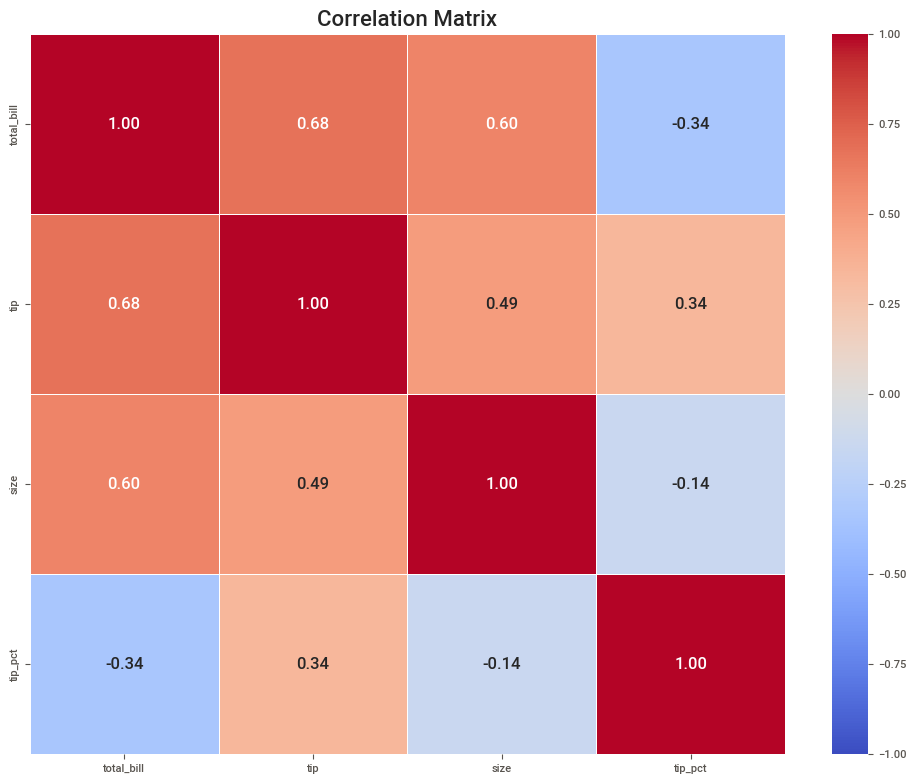

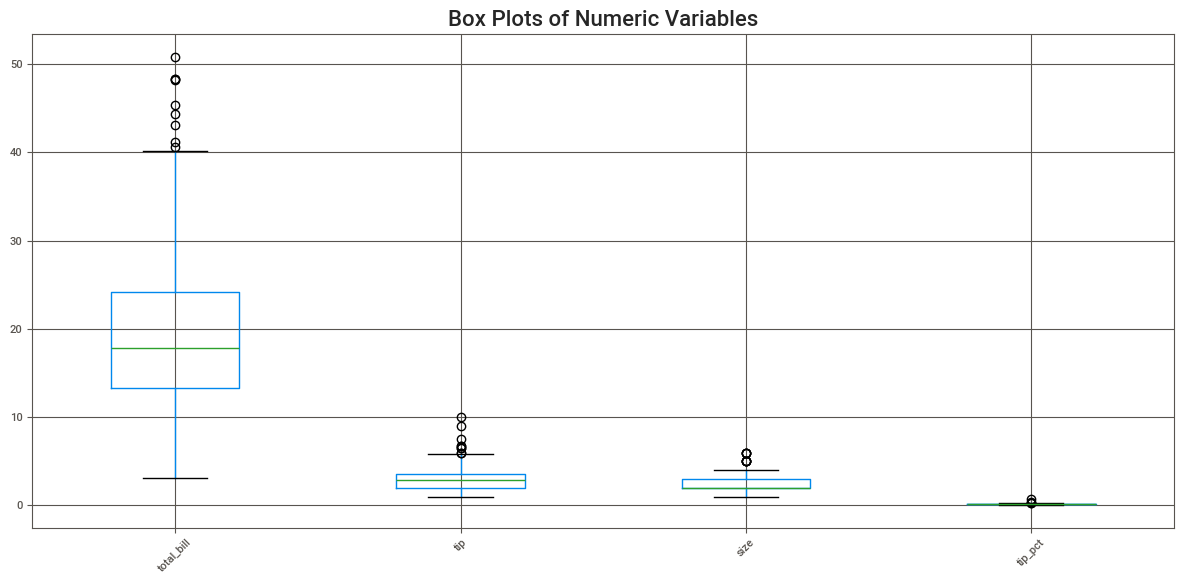

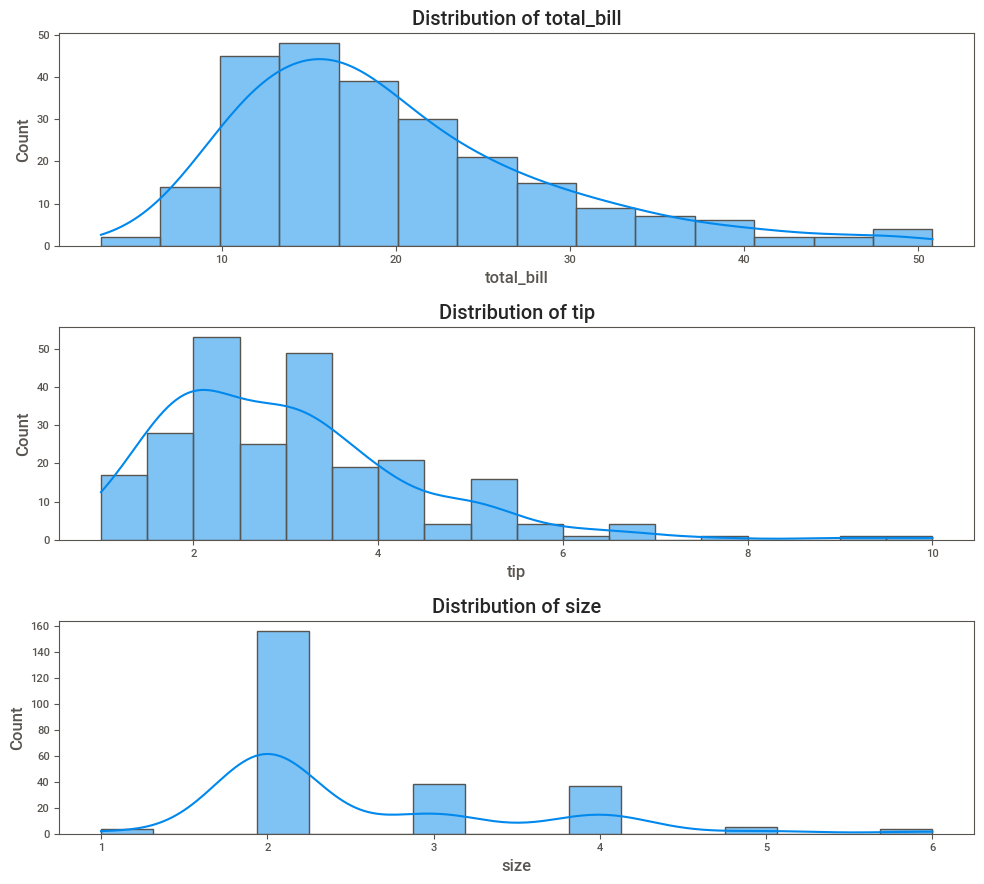

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [20]:
def create_summary_figures(df, filename_prefix=None, save_figures=False):
    """Create a series of summary figures for reporting"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Create a multi-page figure with key visualizations
    figures = []
    
    # 1. Distribution plots for numeric variables
    for i in range(0, len(numeric_cols), 3):  # Process 3 columns per figure
        subset_cols = numeric_cols[i:i+3]
        if len(subset_cols) > 0:
            fig, axes = plt.subplots(len(subset_cols), 1, figsize=(10, 3*len(subset_cols)))
            if len(subset_cols) == 1:
                axes = [axes]
            
            for j, col in enumerate(subset_cols):
                sns.histplot(df[col].dropna(), kde=True, ax=axes[j])
                axes[j].set_title(f'Distribution of {col}')
                axes[j].set_xlabel(col)
            
            plt.tight_layout()
            figures.append(fig)
            
            if save_figures and filename_prefix:
                fig.savefig(f"{filename_prefix}_distributions_{i}.pdf", bbox_inches='tight')
    
    # 2. Correlation heatmap
    if len(numeric_cols) > 1:
        fig = plt.figure(figsize=(10, 8))
        corr_matrix = df[numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                   linewidths=0.5, vmin=-1, vmax=1)
        plt.title("Correlation Matrix", fontsize=16)
        plt.tight_layout()
        figures.append(fig)
        
        if save_figures and filename_prefix:
            fig.savefig(f"{filename_prefix}_correlation.pdf", bbox_inches='tight')
    
    # 3. Box plots
    if len(numeric_cols) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        df[numeric_cols].boxplot(ax=ax)
        plt.title("Box Plots of Numeric Variables", fontsize=16)
        plt.xticks(rotation=45)
        plt.tight_layout()
        figures.append(fig)
        
        if save_figures and filename_prefix:
            fig.savefig(f"{filename_prefix}_boxplots.pdf", bbox_inches='tight')
    
    # Display figures in notebook
    for fig in figures:
        plt.figure(fig.number)
        plt.show()
    
    return figures

# Create summary figures for tips dataset
tips_figures = create_summary_figures(tips_df, "tips", save_figures=False)

# To save the figures, set save_figures=True
# tips_figures = create_summary_figures(tips_df, "tips", save_figures=True)

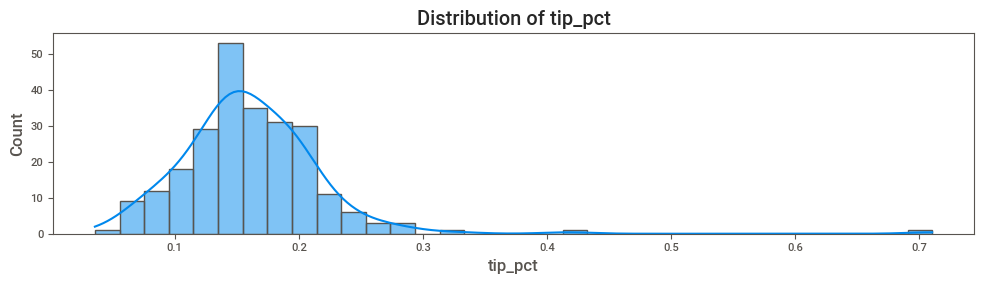

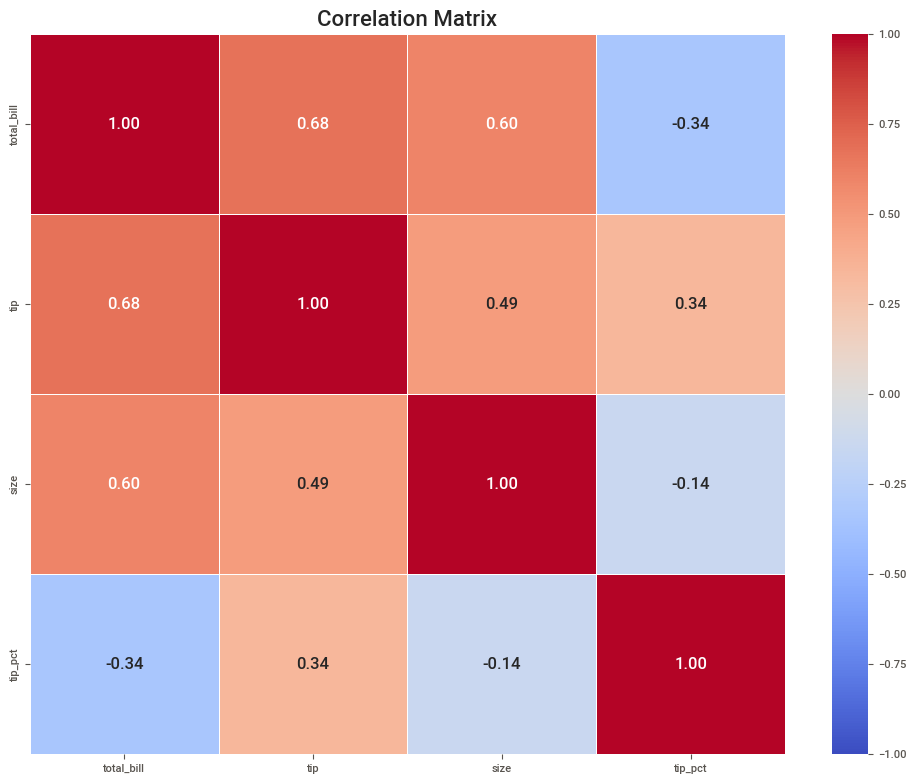

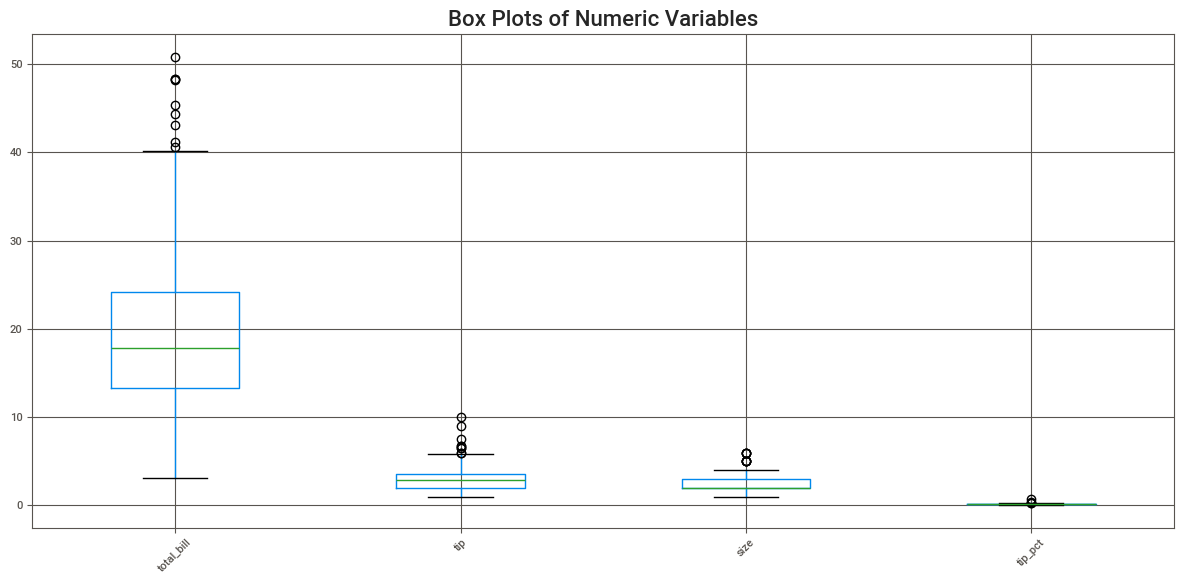

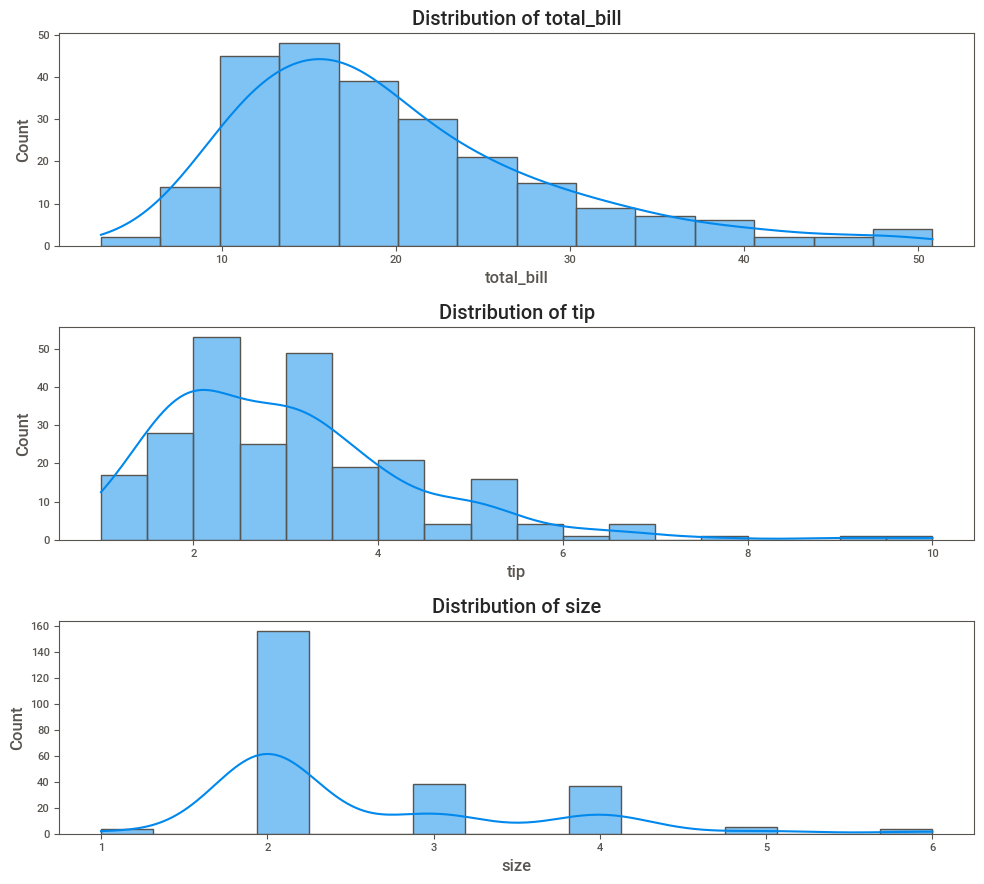

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [21]:
# To save the figures, set save_figures=True
tips_figures = create_summary_figures(tips_df, "tips", save_figures=True)

## Summary

In this notebook, we've covered comprehensive techniques for calculating and reporting summary statistics:

1. **Basic descriptive statistics**: We calculated measures of central tendency, dispersion, and shape.
2. **Advanced statistical summaries**: We created confidence intervals and used groupby operations for segmented analysis.
3. **Visual statistical reporting**: We generated various visualizations to represent our data's statistical properties.
4. **Custom summary functions**: We built tailored reports with outlier detection and comprehensive statistics.
5. **Automated reporting**: We demonstrated how libraries like pandas-profiling can generate extensive reports with minimal code.
6. **Exporting capabilities**: We showed how to export statistics to various formats for sharing with stakeholders.

These techniques provide a solid foundation for any data science project, ensuring that you understand your data thoroughly before proceeding to more advanced analysis or modeling steps.